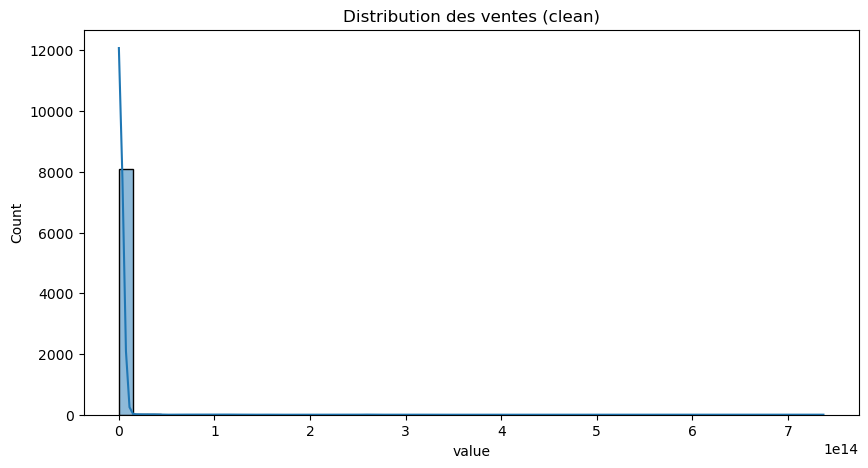

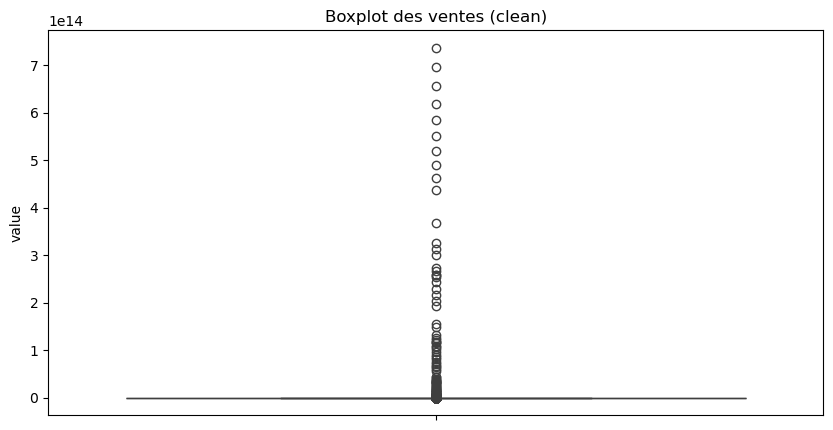

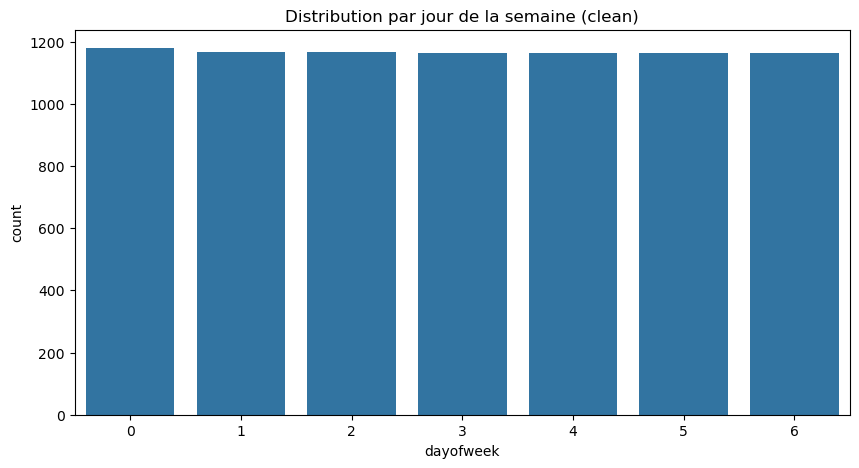

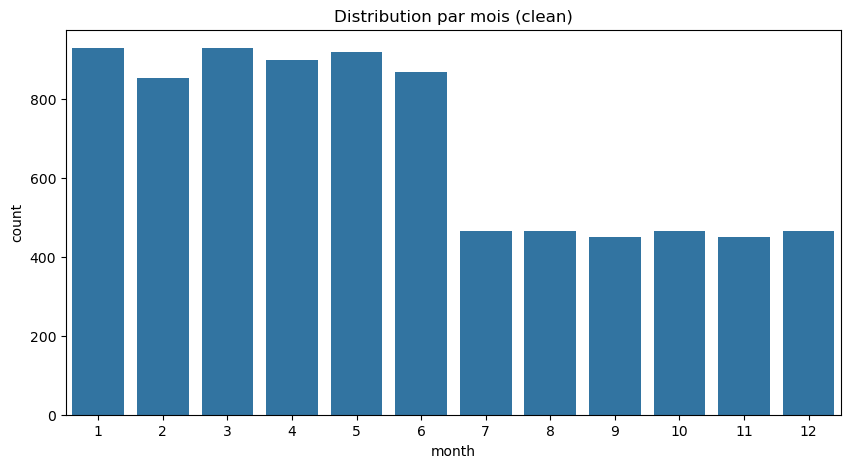

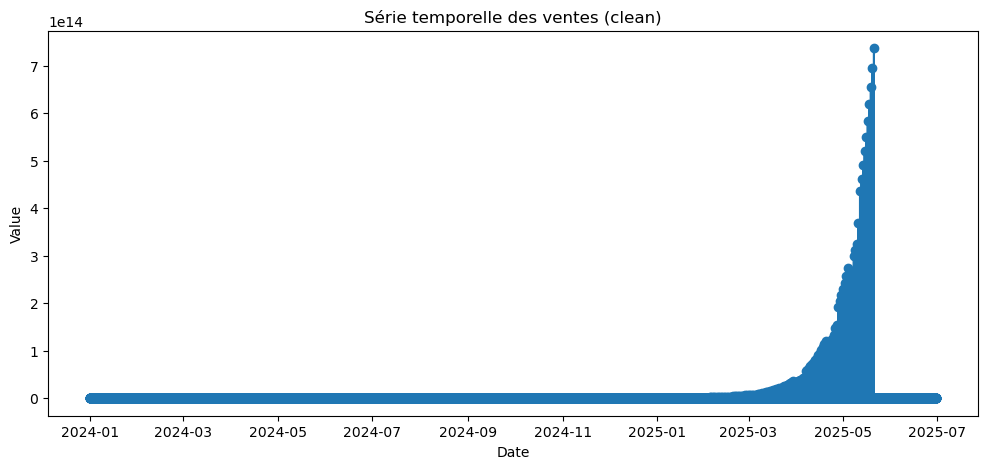

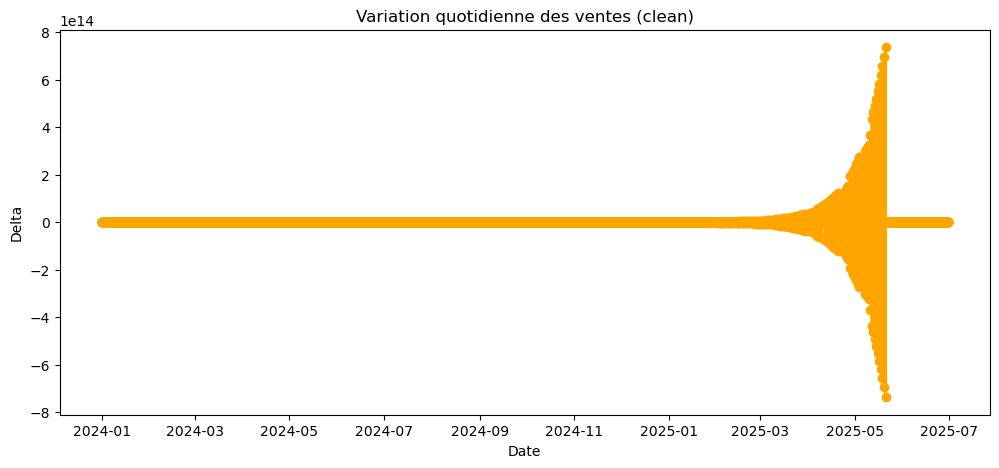

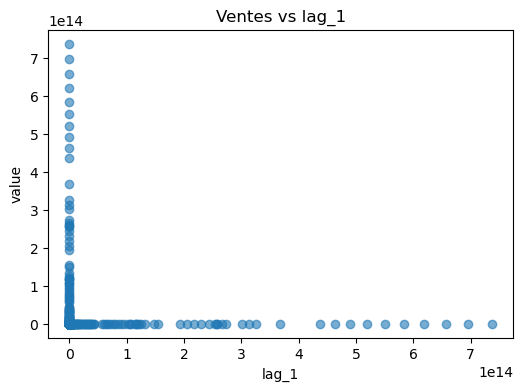

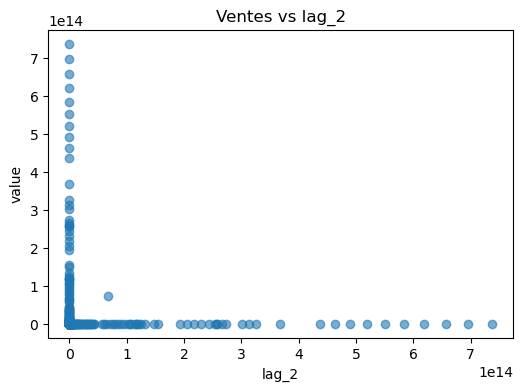

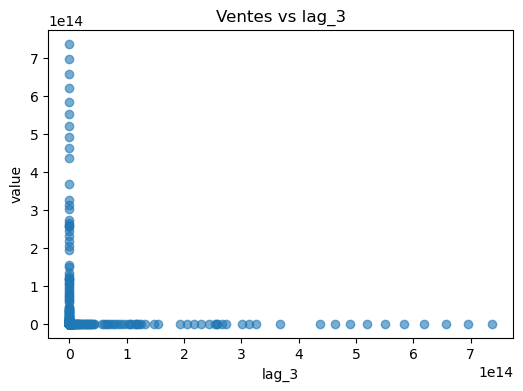

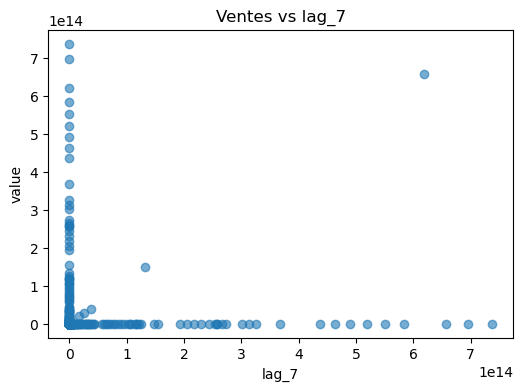

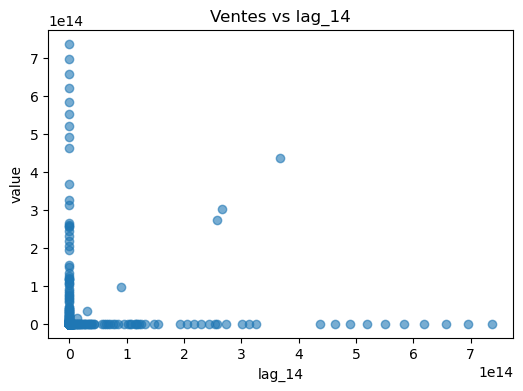

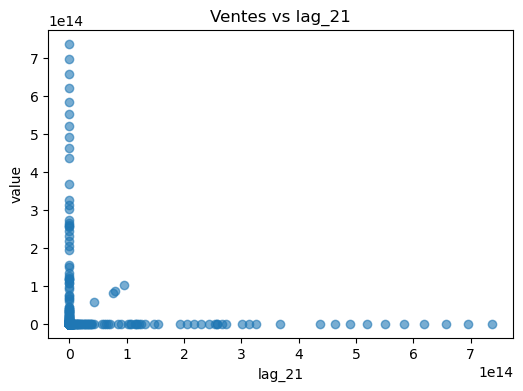

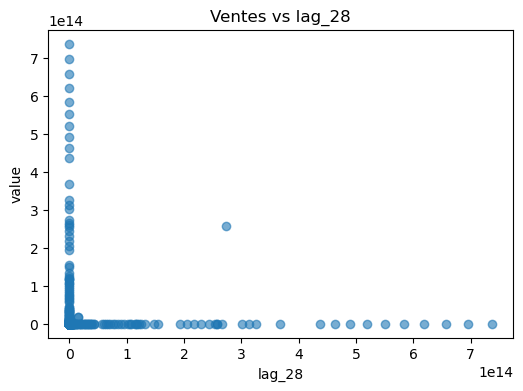

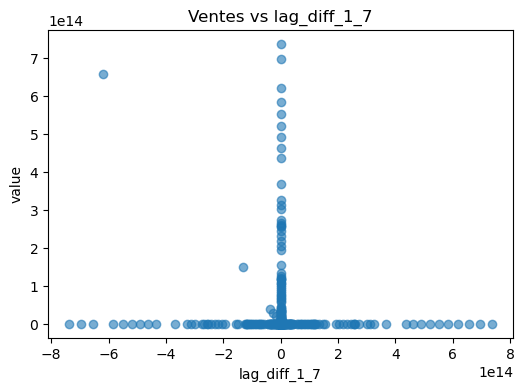

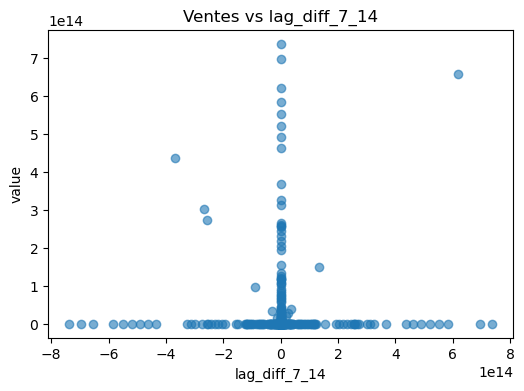

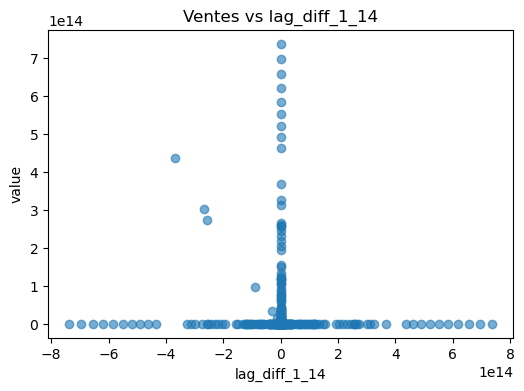

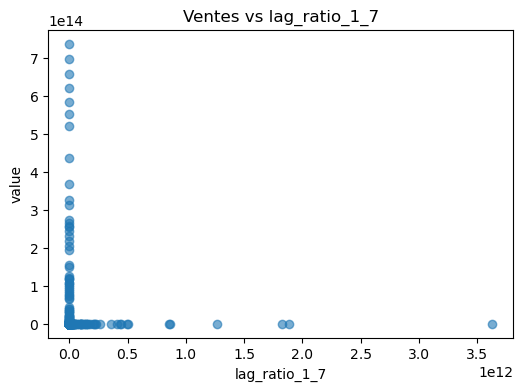

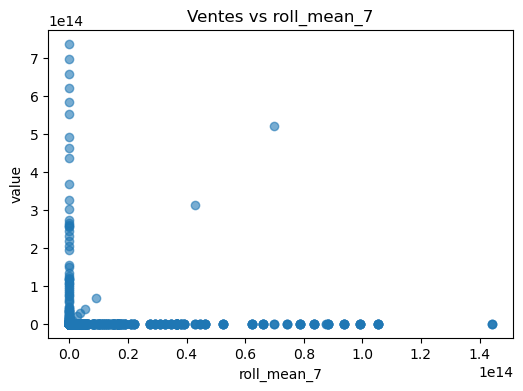

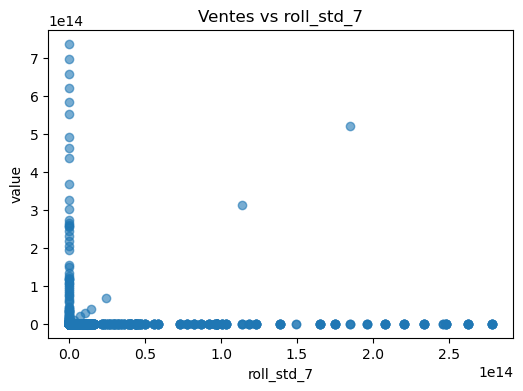

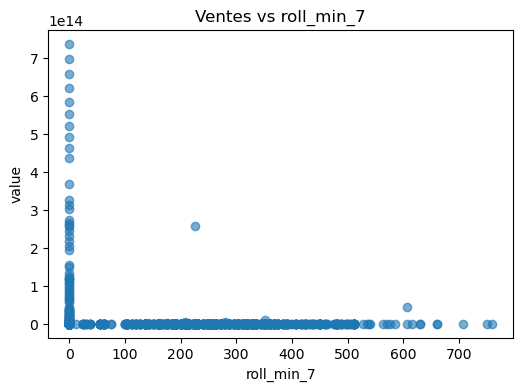

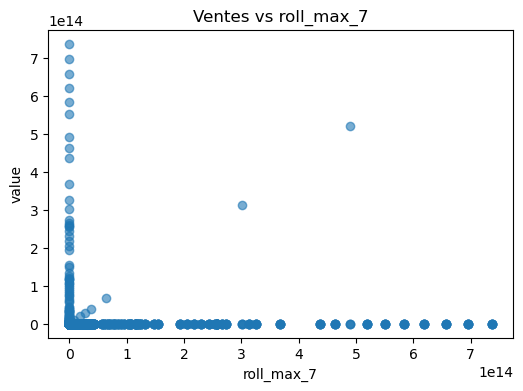

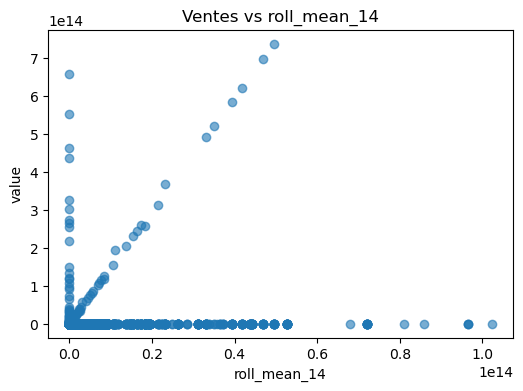

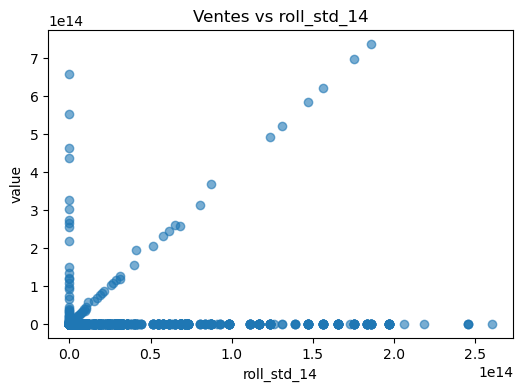

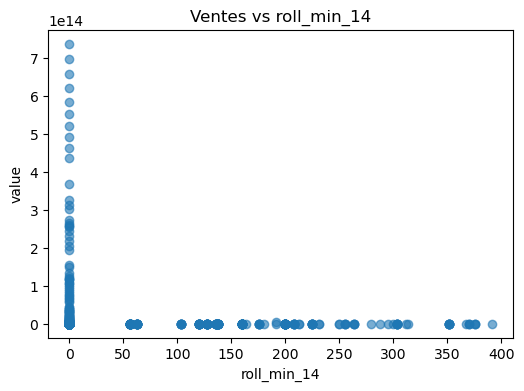

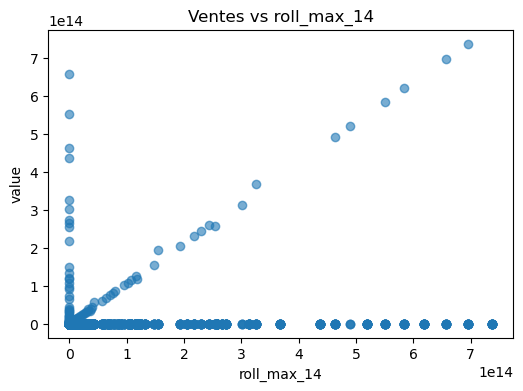

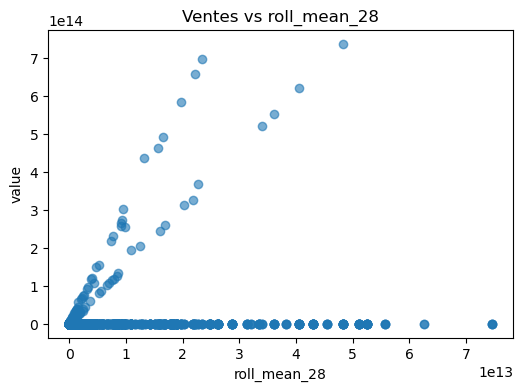

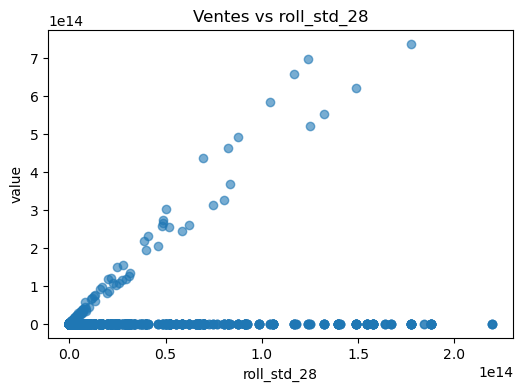

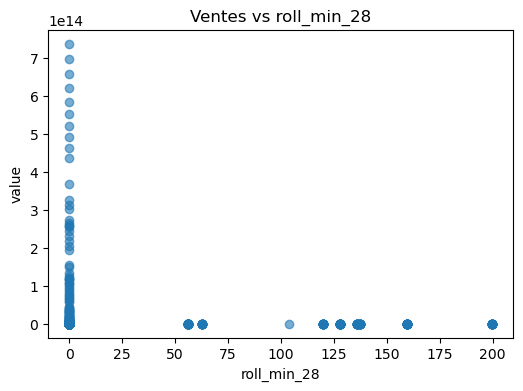

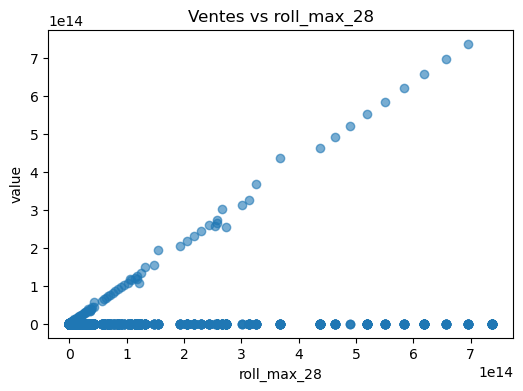

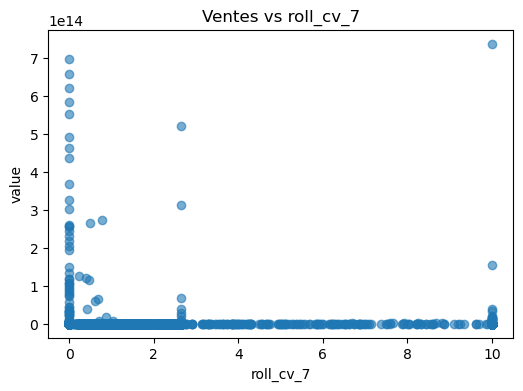

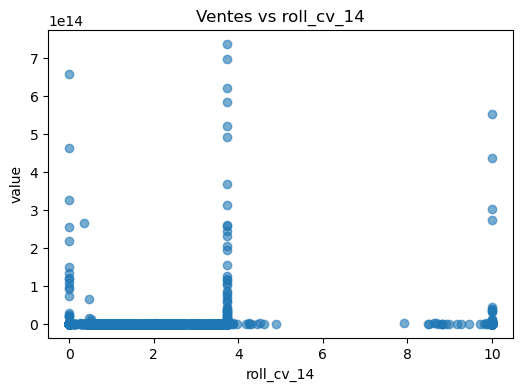

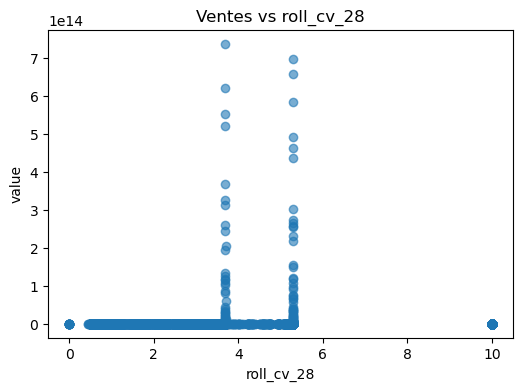

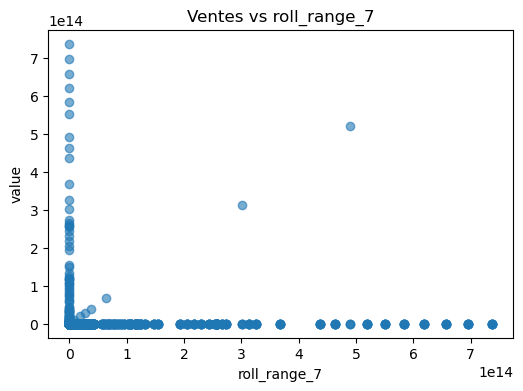

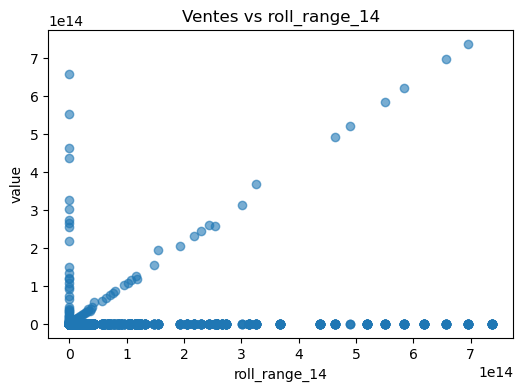

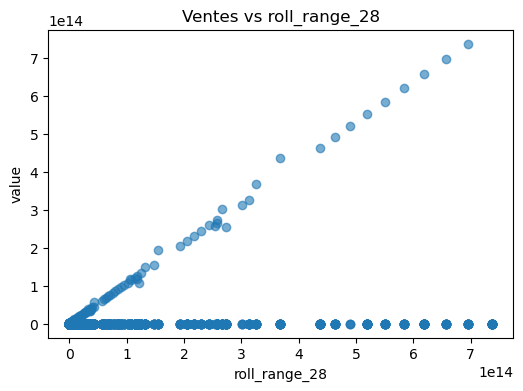

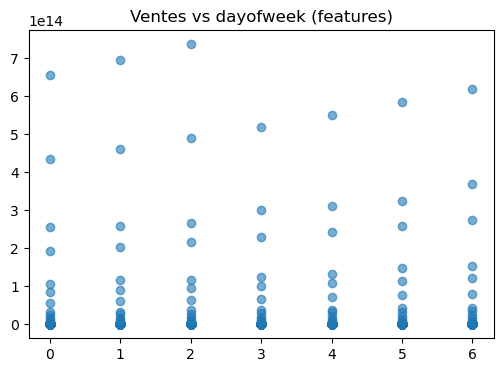

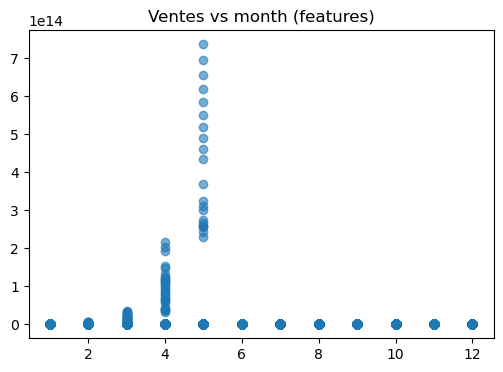

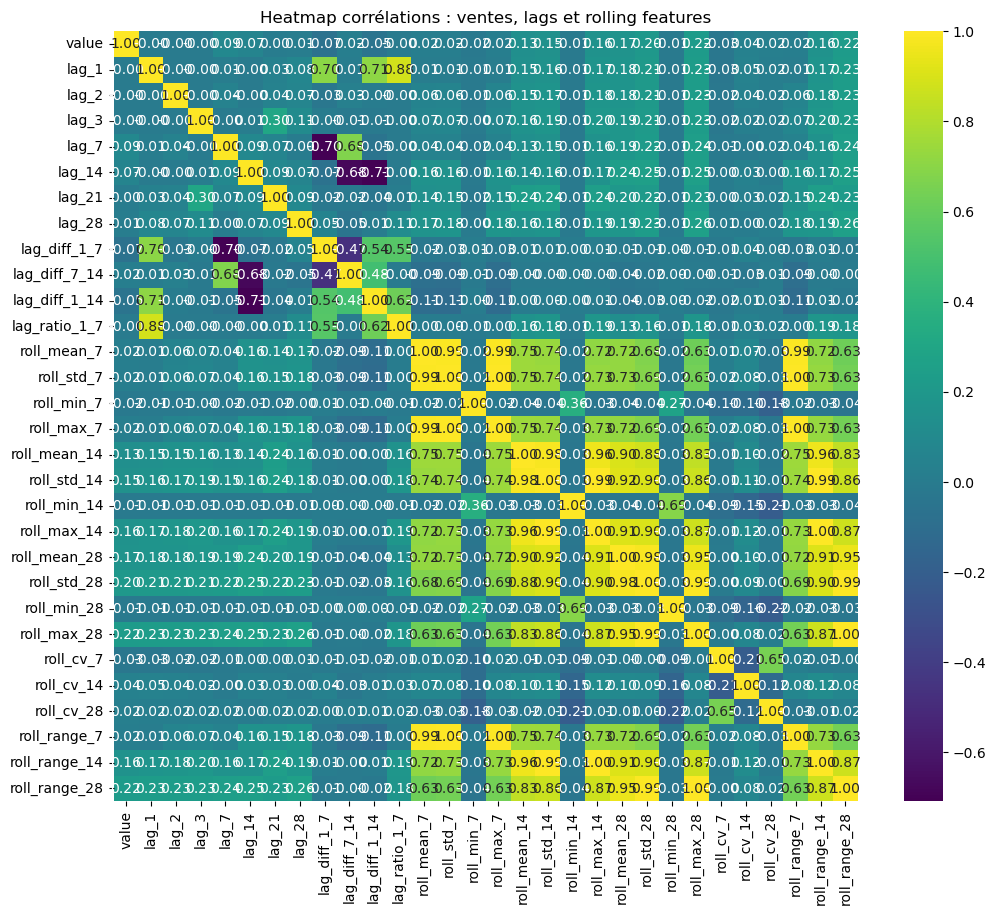

MemoryError: Unable to allocate 37.5 TiB for an array with shape (5153364512804,) and data type float64

In [1]:

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "svg"  # fonctionne dans tous les notebooks

PROJECT_ROOT = Path.cwd().parent
CLEAN_PATH = PROJECT_ROOT / "data" / "interim" / "train_clean.csv"
FEATURES_PATH = PROJECT_ROOT / "data" / "processed" / "train_features.csv"

# Données clean
df_clean = pd.read_csv(CLEAN_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

# Données features
df_feat = pd.read_csv(FEATURES_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

# -----------------------------
# Univariate Analysis sur clean.csv (Matplotlib)
# -----------------------------
plt.figure(figsize=(10,5))
sns.histplot(df_clean['value'], bins=50, kde=True)
plt.title("Distribution des ventes (clean)")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(y=df_clean['value'])
plt.title("Boxplot des ventes (clean)")
plt.show()

# Jour de la semaine
df_clean['dayofweek'] = df_clean['date'].dt.dayofweek
plt.figure(figsize=(10,5))
sns.countplot(x='dayofweek', data=df_clean)
plt.title("Distribution par jour de la semaine (clean)")
plt.show()

# Mois
df_clean['month'] = df_clean['date'].dt.month
plt.figure(figsize=(10,5))
sns.countplot(x='month', data=df_clean)
plt.title("Distribution par mois (clean)")
plt.show()

# Série temporelle
plt.figure(figsize=(12,5))
plt.plot(df_clean['date'], df_clean['value'], marker='o')
plt.title("Série temporelle des ventes (clean)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.show()

# Variation quotidienne
df_clean['delta'] = df_clean['value'].diff()
plt.figure(figsize=(12,5))
plt.plot(df_clean['date'], df_clean['delta'], marker='o', color='orange')
plt.title("Variation quotidienne des ventes (clean)")
plt.xlabel("Date")
plt.ylabel("Delta")
plt.show()

# -----------------------------
# Bivariate Analysis sur features.csv
# -----------------------------
lag_cols = [c for c in df_feat.columns if "lag_" in c]
roll_cols = [c for c in df_feat.columns if "roll_" in c]

# Scatter plots avec Matplotlib
for col in lag_cols + roll_cols:
    plt.figure(figsize=(6,4))
    plt.scatter(df_feat[col], df_feat['value'], alpha=0.6)
    plt.xlabel(col)
    plt.ylabel("value")
    plt.title(f"Ventes vs {col}")
    plt.show()

# Features calendaires
plt.figure(figsize=(6,4))
plt.scatter(df_feat['dayofweek'], df_feat['value'], alpha=0.6)
plt.title("Ventes vs dayofweek (features)")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df_feat['month'], df_feat['value'], alpha=0.6)
plt.title("Ventes vs month (features)")
plt.show()

# -----------------------------
#  Corrélation et Heatmap
# -----------------------------
corr_cols = ['value'] + lag_cols + roll_cols
plt.figure(figsize=(12,10))
sns.heatmap(df_feat[corr_cols].corr(), annot=True, fmt=".2f", cmap="viridis")
plt.title("Heatmap corrélations : ventes, lags et rolling features")
plt.show()

# -----------------------------
#  Pair plot avec Seaborn (statique)
# -----------------------------
sns.pairplot(df_feat[corr_cols].sample(min(500, len(df_feat))))  # échantillon si trop gros
plt.suptitle("Pair plot : ventes, lags et rolling features", y=1.02)
plt.show()


